## Pytorch classify MNIST digits example and experiment tracking with mlflow
This notebook presents machine learning process for image classification of road signs.
1. Import data
2. Analyze data
3. Augment images
5. Train Model
6. Evaluate model

In [1]:
! pip install mlflow torch torchvision

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
import shutil
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, TensorSpec
import numpy as np

# SQLite backend instead of deprecated filesystem backend
tracking_db = Path("../model/mlflow.db").resolve()
tracking_db.parent.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{tracking_db}")
mlflow.set_experiment("image_digit_classification_mnist")

input_size = 28 * 28
hidden_size = 100
output_size = 10
learning_rate = 0.001
batch_size = 100
epochs = 5

train_dataset = torchvision.datasets.MNIST(
    root="../data",
    train=True,
    transform=transforms.ToTensor(),
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="../data",
    train=False,
    transform=transforms.ToTensor(),
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
)


class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out


model = NeuralNet(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

run = mlflow.start_run()
mlflow.log_param("input_size", input_size)
mlflow.log_param("hidden_size", hidden_size)
mlflow.log_param("output_size", output_size)
mlflow.log_param("learning_rate", learning_rate)
mlflow.log_param("batch_size", batch_size)
mlflow.log_param("epochs", epochs)

for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        output = model(data.reshape(-1, input_size))
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        step = epoch * len(train_loader) + batch_idx
        mlflow.log_metric("train_loss", loss.item(), step=step)

        if batch_idx % 10 == 0:
            print(f"epoch={epoch + 1}, batch={batch_idx}, loss={loss.item():.4f}")

epoch=1, batch=0, loss=2.2852
epoch=1, batch=10, loss=1.8790
epoch=1, batch=20, loss=1.4464
epoch=1, batch=30, loss=1.0838
epoch=1, batch=40, loss=0.8429
epoch=1, batch=50, loss=0.7127
epoch=1, batch=60, loss=0.5463
epoch=1, batch=70, loss=0.4528
epoch=1, batch=80, loss=0.6444
epoch=1, batch=90, loss=0.3416
epoch=1, batch=100, loss=0.4153
epoch=1, batch=110, loss=0.3913
epoch=1, batch=120, loss=0.3834
epoch=1, batch=130, loss=0.3874
epoch=1, batch=140, loss=0.4675
epoch=1, batch=150, loss=0.3296
epoch=1, batch=160, loss=0.4558
epoch=1, batch=170, loss=0.4774
epoch=1, batch=180, loss=0.5541
epoch=1, batch=190, loss=0.3317
epoch=1, batch=200, loss=0.3708
epoch=1, batch=210, loss=0.2437
epoch=1, batch=220, loss=0.3829
epoch=1, batch=230, loss=0.3425
epoch=1, batch=240, loss=0.5182
epoch=1, batch=250, loss=0.3632
epoch=1, batch=260, loss=0.2647
epoch=1, batch=270, loss=0.3228
epoch=1, batch=280, loss=0.2499
epoch=1, batch=290, loss=0.3413
epoch=1, batch=300, loss=0.2885
epoch=1, batch=310,

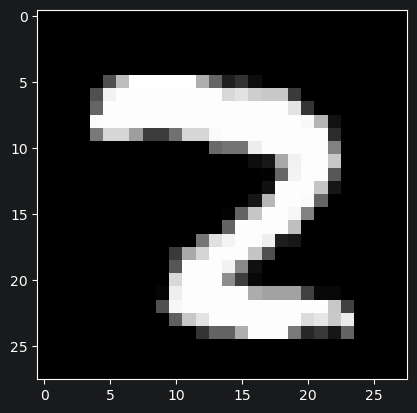

2


<Figure size 640x480 with 0 Axes>

In [3]:
plt.imshow(train_dataset[28][0].reshape(28, 28), cmap='gray')
plt.show()
plt.savefig("number_plot.png")
mlflow.log_artifact("number_plot.png")

print(train_dataset[28][1])


In [4]:
run = mlflow.active_run()
run_id = run.info.run_id

model.eval()

input_example = torch.randn(2, input_size, dtype=torch.float32)

signature = ModelSignature(
    inputs=Schema([
        TensorSpec(np.dtype(np.float32), (-1, input_size))
    ]),
    outputs=Schema([
        TensorSpec(np.dtype(np.float32), (-1, output_size))
    ]),
)

mlflow.pytorch.log_model(
    pytorch_model=model,
    name="mnist_pytorch_model",
    registered_model_name="my_registered_model",
    serialization_format="pt2",
    input_example=input_example,
    signature=signature,
)

local_model_path = Path("../model") / f"my-model-{run_id}"

if local_model_path.exists():
    shutil.rmtree(local_model_path)

mlflow.pytorch.save_model(
    pytorch_model=model,
    path=str(local_model_path),
    serialization_format="pt2",
    input_example=input_example,
    signature=signature,
)

2026/06/18 10:13:11 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpnuipvotu/model/data, flavor: pytorch). Fall back to return ['torch==2.12.1', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 
Registered model 'my_registered_model' already exists. Creating a new version of this model...
Created version '3' of model 'my_registered_model'.
2026/06/18 10:13:16 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /home/mzar/mlops-practical-examples/notebooks/model/my-model-8873260722554701b4219900e457a7e8/data, flavor: pytorch). Fall back to return ['torch==2.12.1', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


Accuracy: 0.9686
2 2


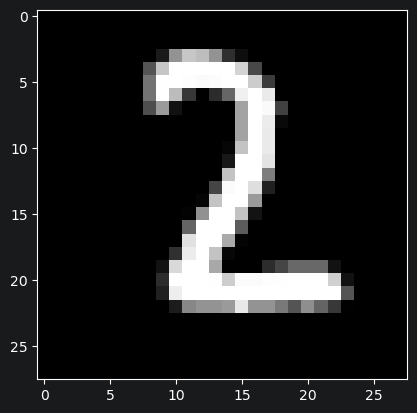

5 5


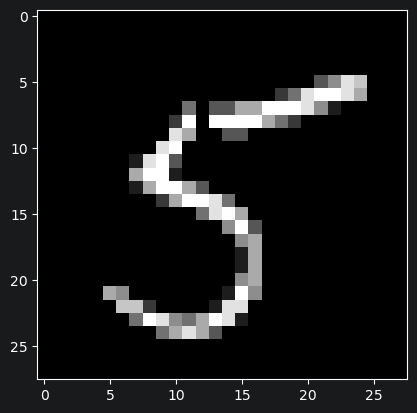

8 8


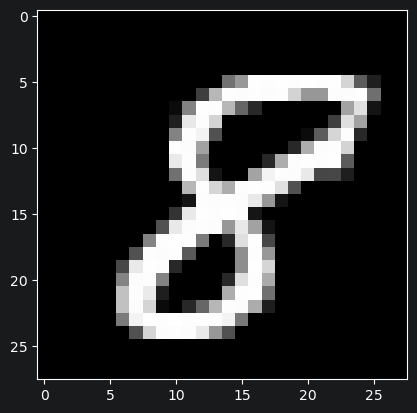

6 6


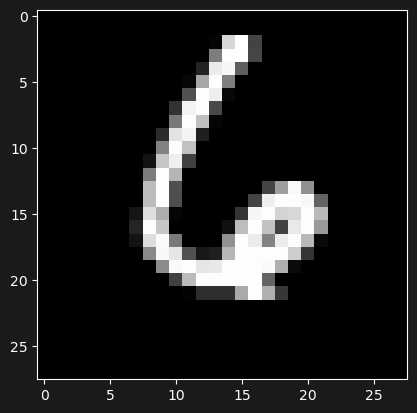

1 1


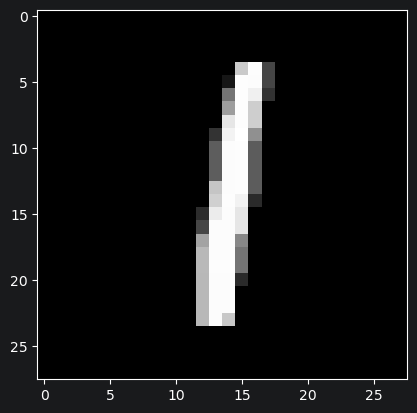

7 7


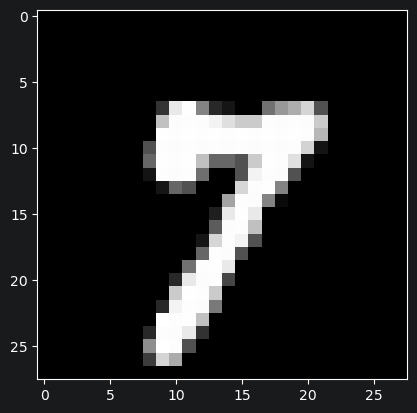

3 3


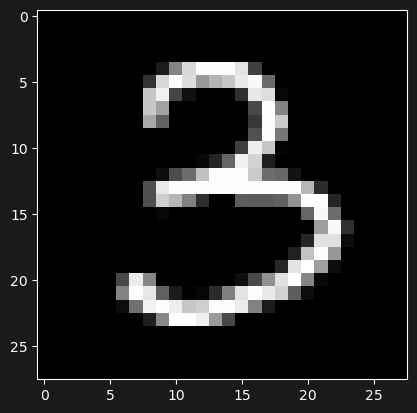

8 8


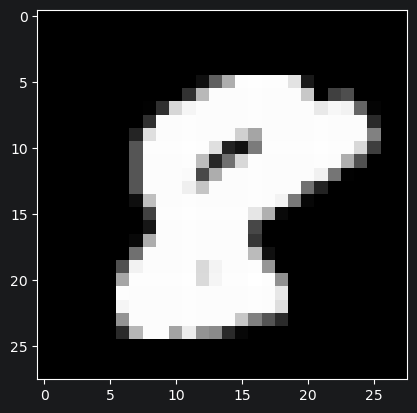

4 4


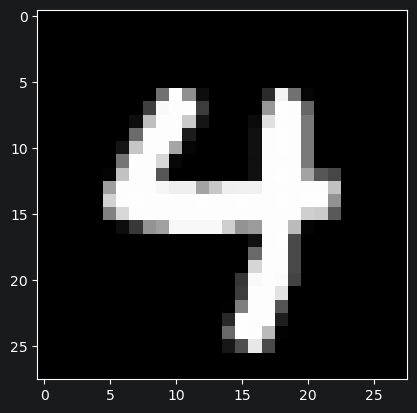

9 9


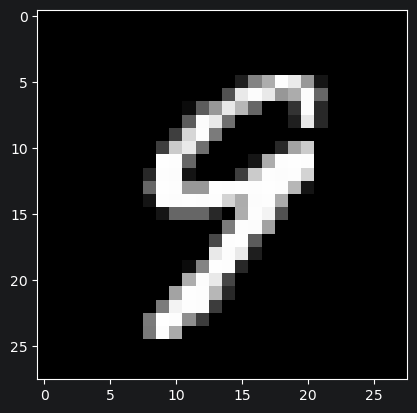

0 0


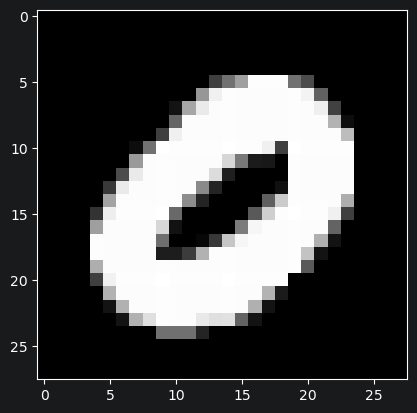

8 8


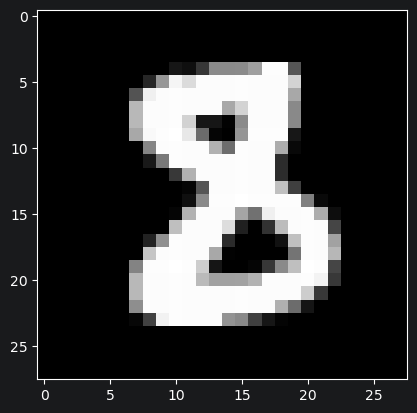

9 9


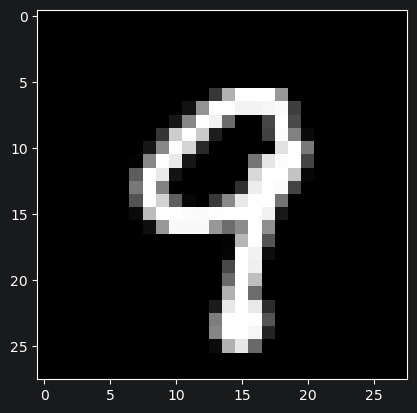

9 9


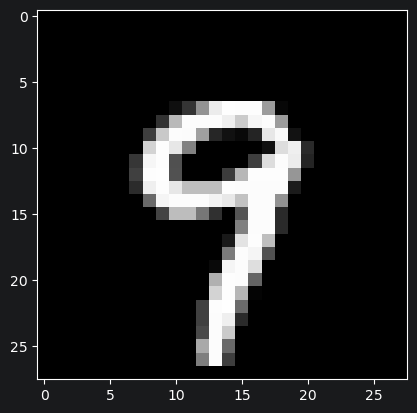

5 5


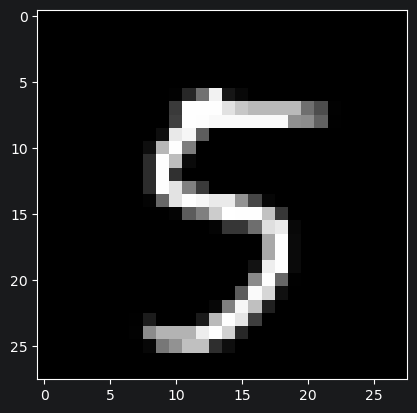

7 7


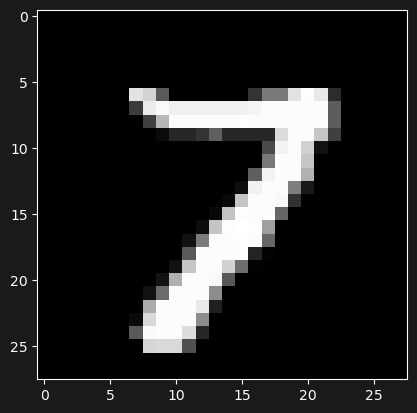

4 4


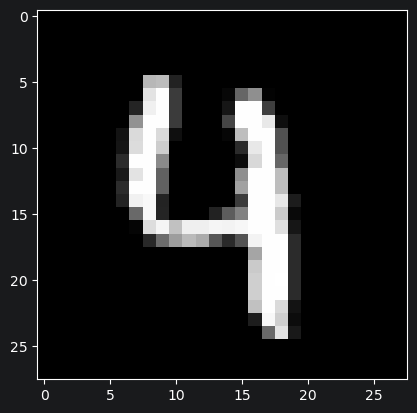

8 8


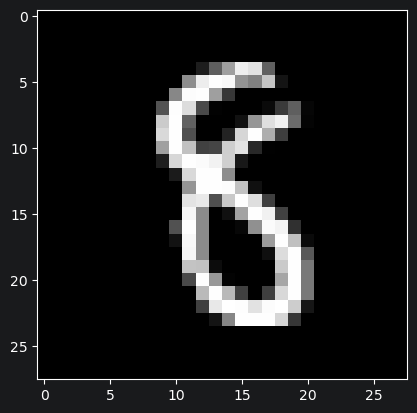

5 5


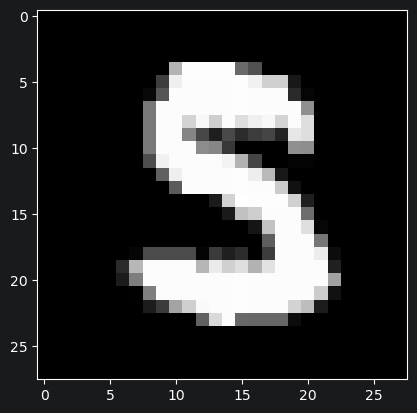

0 0


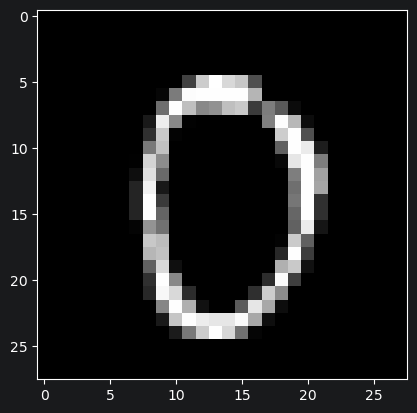

3 3


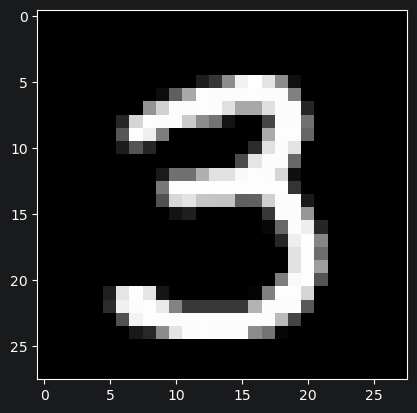

7 2


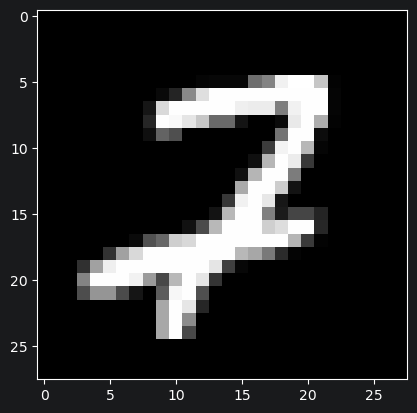

8 8


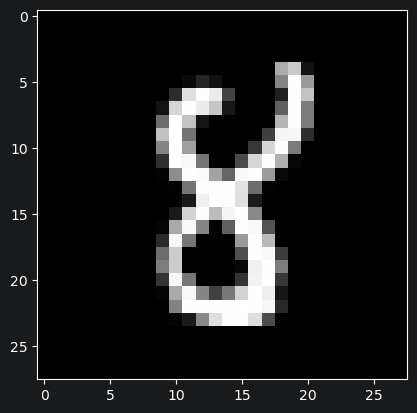

6 6


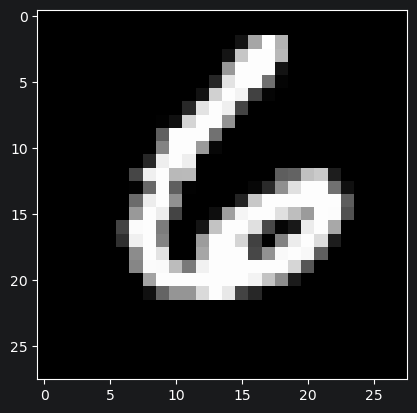

0 0


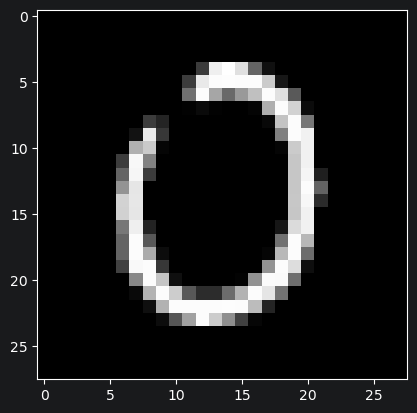

5 5


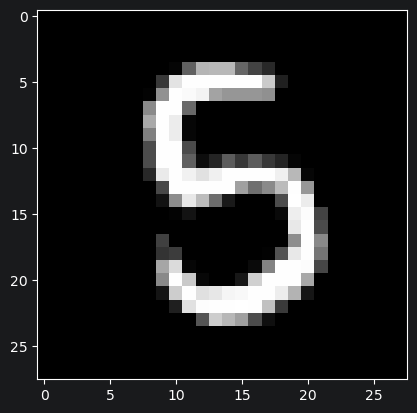

0 0


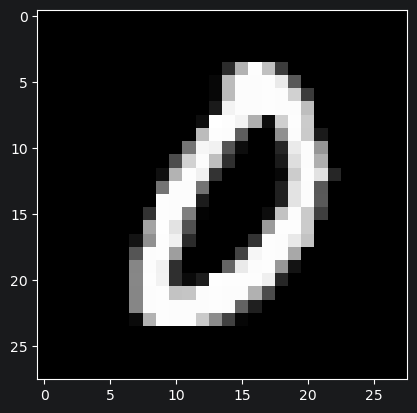

1 1


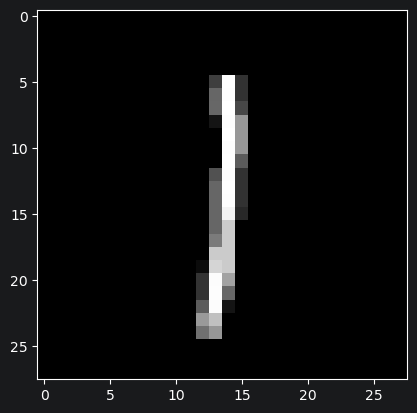

1 1


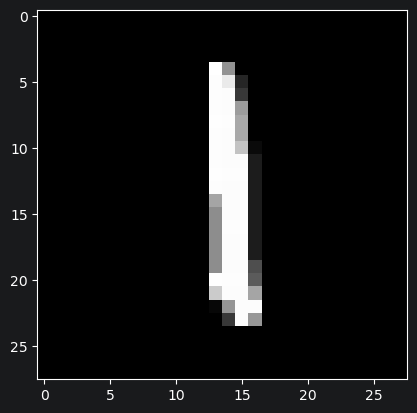

9 9


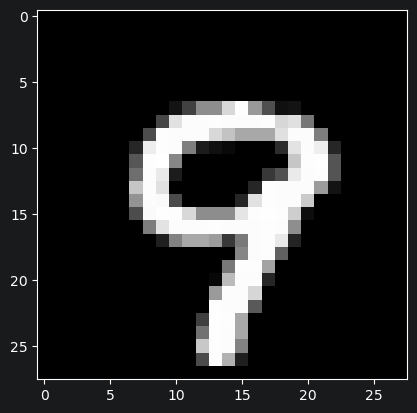

2 2


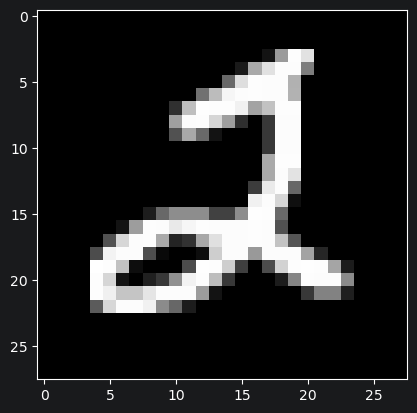

9 9


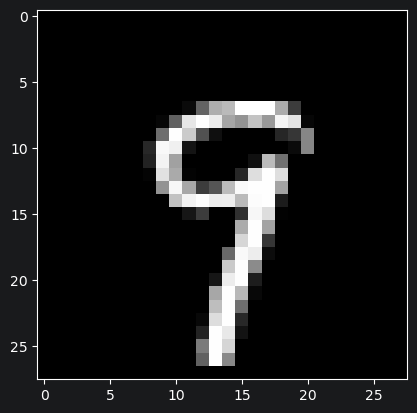

6 6


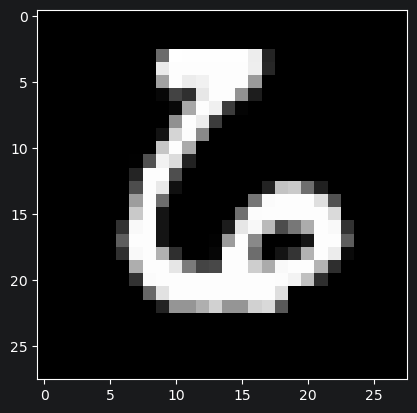

3 3


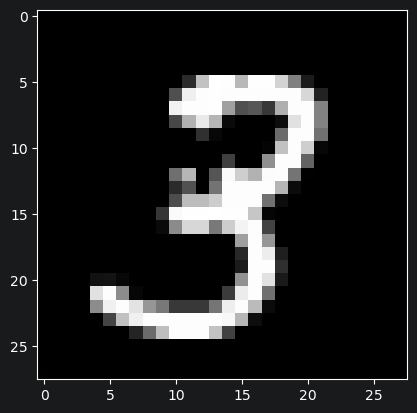

0 0


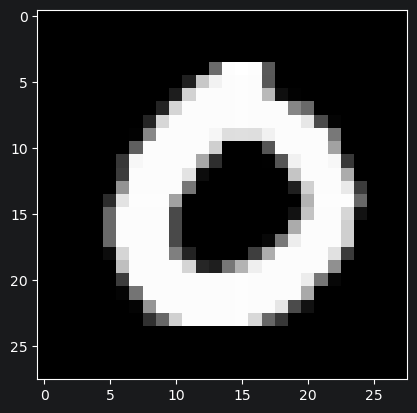

5 5


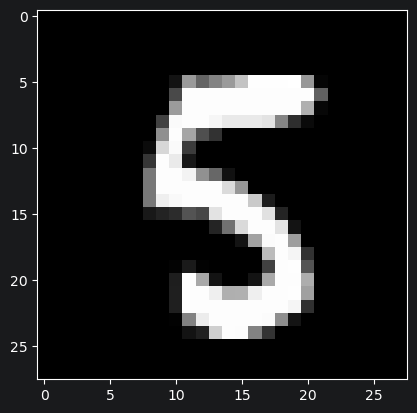

1 1


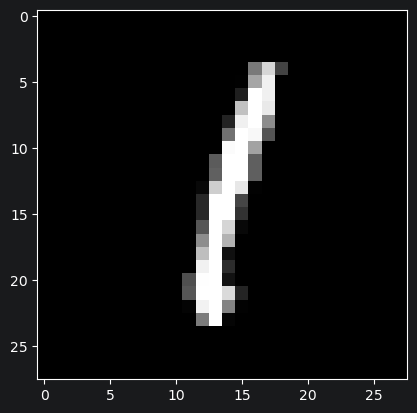

5 5


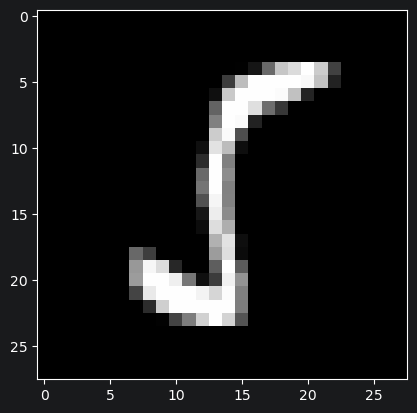

4 4


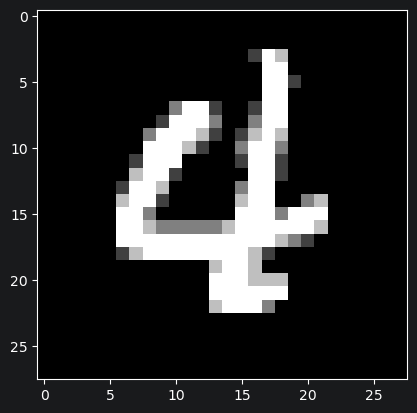

1 1


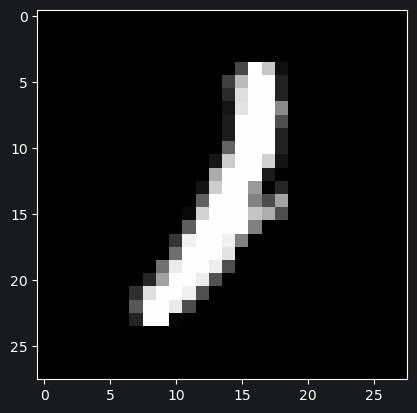

6 6


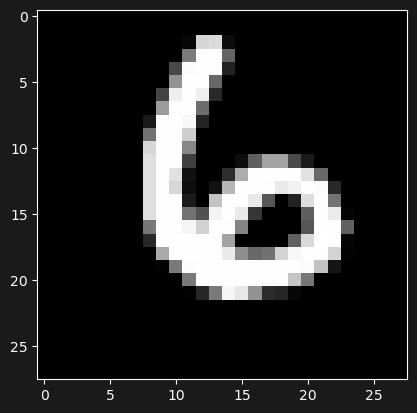

9 9


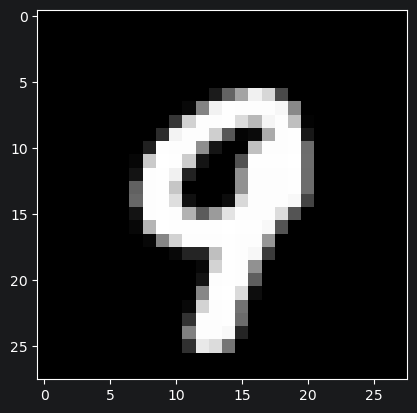

1 1


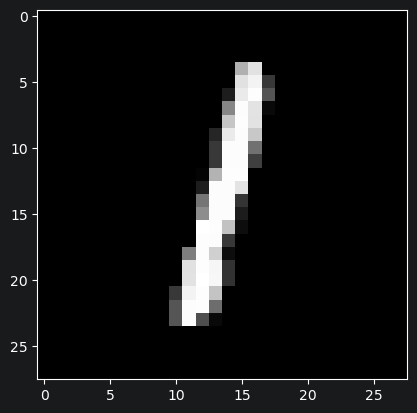

7 7


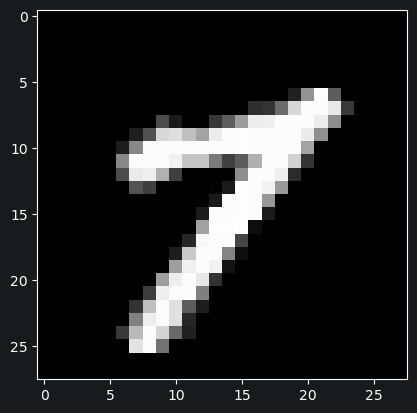

8 8


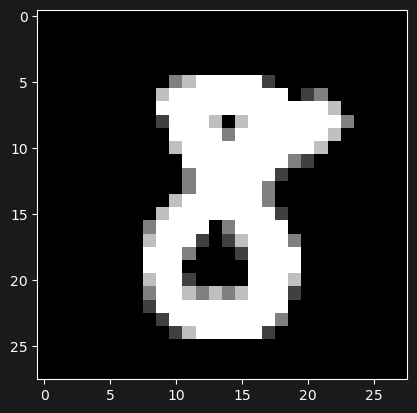

9 9


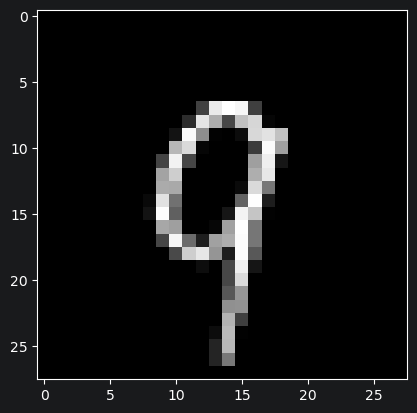

2 2


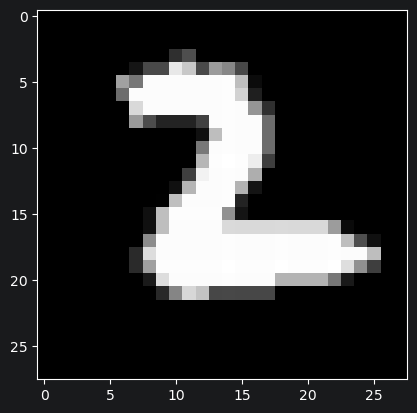

3 3


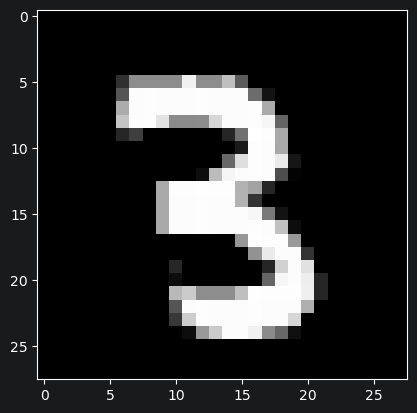

7 7


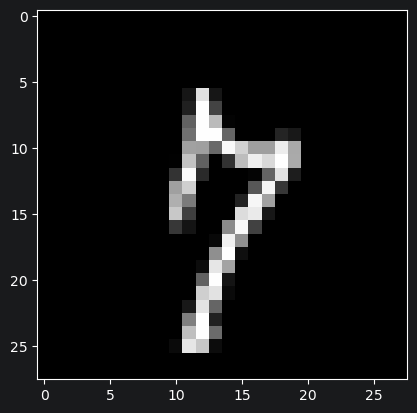

0 0


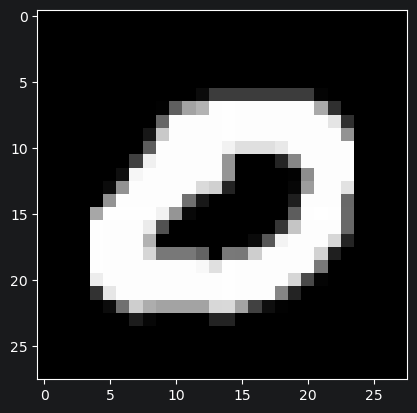

1 1


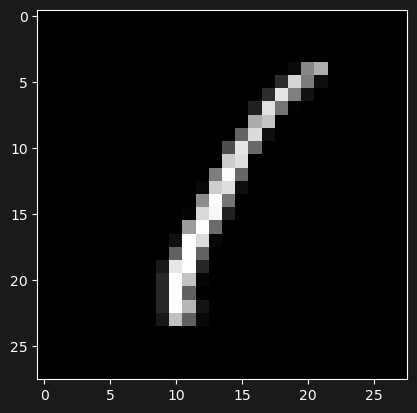

2 2


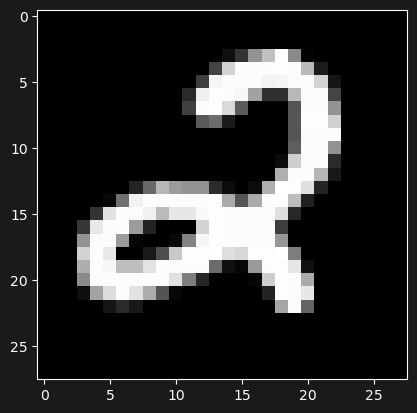

6 6


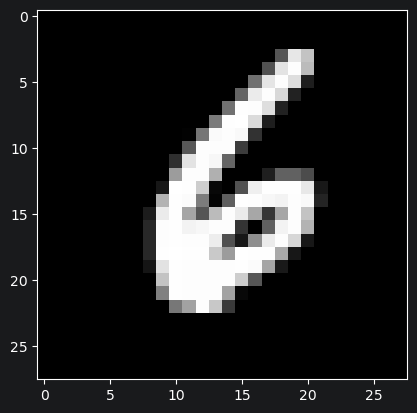

6 6


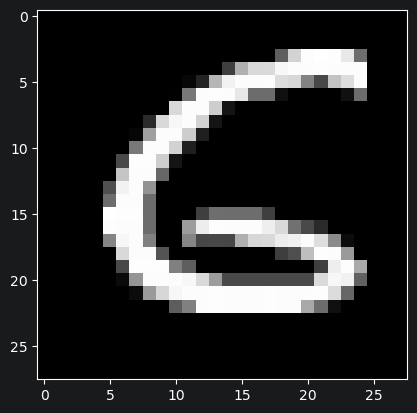

1 1


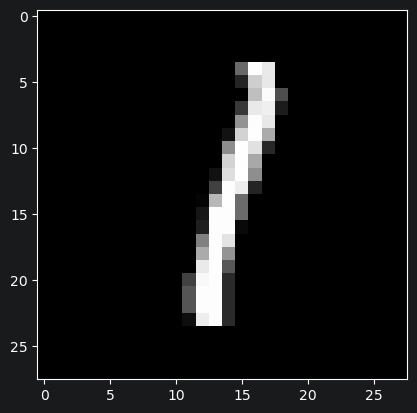

4 4


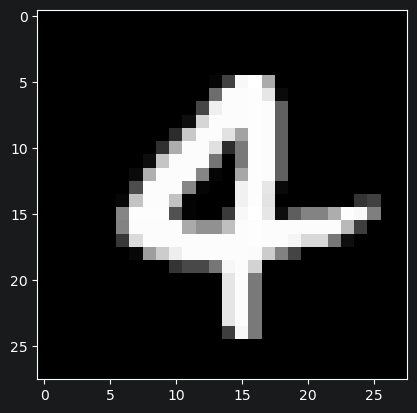

3 3


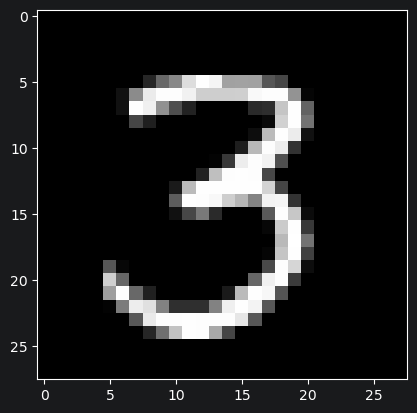

1 1


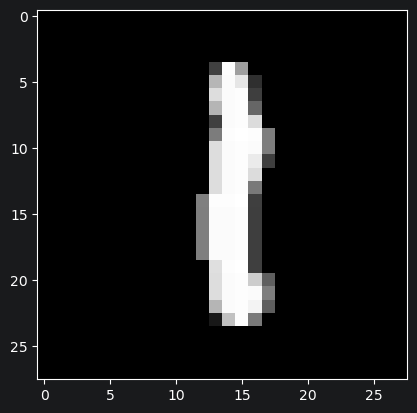

2 2


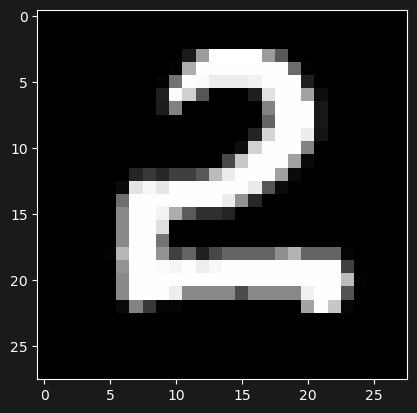

5 5


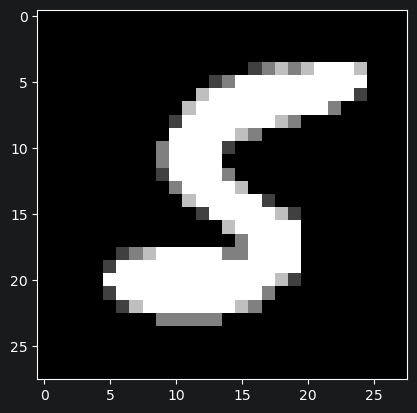

1 1


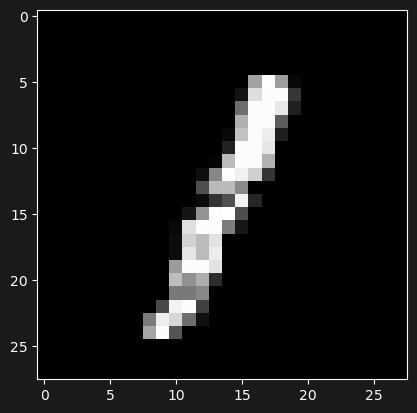

4 4


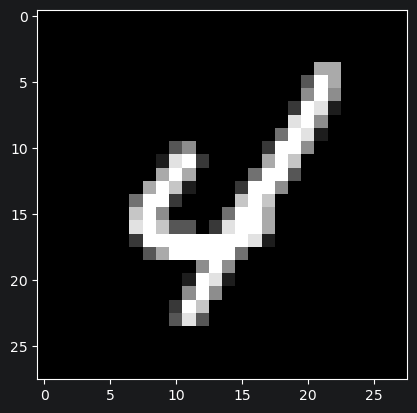

5 5


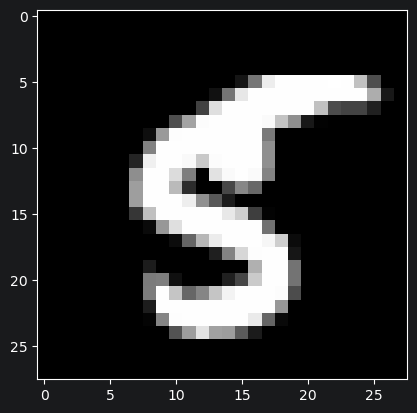

7 7


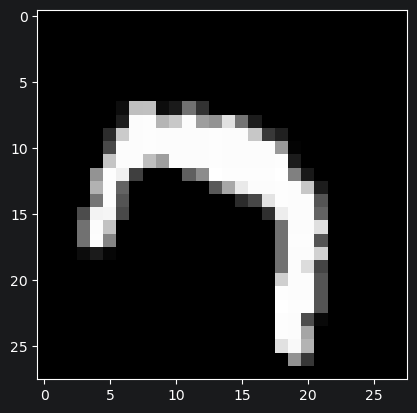

0 0


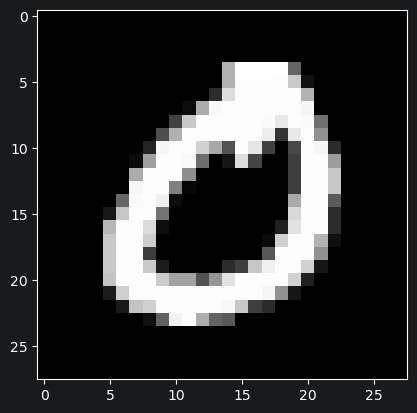

0 0


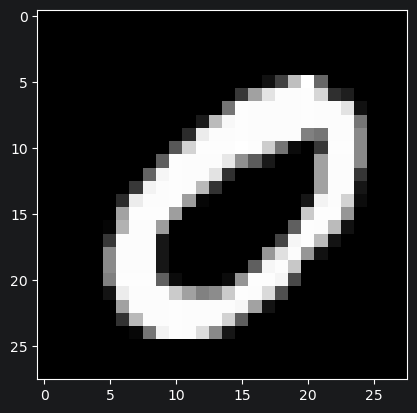

In [5]:
all = 0
correct = 0
for i, (inputs, labels) in enumerate(test_loader):
    predicted = model(inputs.reshape(-1, input_size))
    all += labels.size(0)
    for j, label in enumerate(labels):
        if label.item() == predicted[j].argmax().item():
            correct += 1

print(f'Accuracy: {correct / all}')
mlflow.log_param("test_accuracy", correct / all)
mlflow.end_run()

for i, (inputs, labels) in enumerate(test_loader):
    predicted = model(inputs.reshape(-1, input_size))
    for j, label in enumerate(labels):
        print(label.item(), predicted[j].argmax().item())
        plt.imshow(inputs[j][0], cmap='gray')
        plt.show()
        if j == 10:
            break
    if i == 5:
        break

Uruchom panel UI MLFlow w przeglądarce:

```
mlflow server \
  --backend-store-uri sqlite:///../model/mlflow.db \
  --default-artifact-root ./mlruns \
  --host 127.0.0.1 \
  --port 5000
 ```